In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

Matplotlib is building the font cache; this may take a moment.


All imports successful


In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (577347, 12)
Test shape: (247435, 11)


In [3]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [5]:
print("Column dtypes:")
print(train.dtypes)
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nMissing values in test:")
print(test.isnull().sum())

Column dtypes:
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object

Missing values in train:
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

Missing values in test:
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
dtype: int64


In [6]:
print("Class distribution:")
print(train['class'].value_counts())
print("\nClass distribution (%):")
print(train['class'].value_counts(normalize=True).round(3) * 100)

Class distribution:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

Class distribution (%):
class
GALAXY    65.4
QSO       20.3
STAR      14.3
Name: proportion, dtype: float64


In [7]:
print("Basic statistics:")
train.describe().round(3)

Basic statistics:


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.000,577347.000,577347.000,577347.000,577347.000,577347.000,577347.000,577347.000,577347.000
mean,288673.000,181.617,21.835,22.442,21.007,19.963,19.379,19.041,0.723
std,166665.867,96.243,18.934,2.018,1.795,1.649,1.580,1.584,0.810
min,0.000,0.012,-17.967,-0.139,13.535,12.579,11.963,11.683,-0.010
25%,144336.500,132.161,2.474,20.977,19.865,18.821,18.307,17.973,0.181
50%,288673.000,188.681,21.484,22.570,21.468,20.431,19.632,19.189,0.498
75%,433009.500,231.830,36.988,23.869,22.293,21.164,20.608,20.162,0.881
max,577346.000,360.000,79.158,28.253,27.620,25.254,27.911,26.827,7.011


In [8]:
print("Redshift statistics by class:")
train.groupby('class')['redshift'].describe().round(3)

Redshift statistics by class:


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,0.509,0.309,-0.01,0.267,0.482,0.715,6.860
QSO,117143.0,1.876,1.070,0.00,1.132,1.799,2.506,7.011
STAR,82724.0,0.068,0.064,-0.01,0.022,0.056,0.102,5.445


In [9]:
print("Spectral type unique values:")
print(train['spectral_type'].unique())
print("\nGalaxy population unique values:")
print(train['galaxy_population'].unique())

Spectral type unique values:
<StringArray>
['M', 'O/B', 'G/K', 'A/F']
Length: 4, dtype: str

Galaxy population unique values:
<StringArray>
['Red_Sequence', 'Blue_Cloud']
Length: 2, dtype: str


In [10]:
print("Spectral type by class:")
print(pd.crosstab(train['class'], train['spectral_type'], normalize='index').round(3))
print("\nGalaxy population by class:")
print(pd.crosstab(train['class'], train['galaxy_population'], normalize='index').round(3))

Spectral type by class:
spectral_type    A/F    G/K      M    O/B
class                                    
GALAXY         0.064  0.163  0.763  0.010
QSO            0.525  0.179  0.033  0.263
STAR           0.440  0.314  0.138  0.108

Galaxy population by class:
galaxy_population  Blue_Cloud  Red_Sequence
class                                      
GALAXY                  0.236         0.764
QSO                     0.924         0.076
STAR                    0.732         0.268


In [11]:
# How many outliers does each class have in redshift
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((data < lower) | (data > upper)).sum()

print("Redshift outliers per class:")
for cls in ['GALAXY', 'QSO', 'STAR']:
    data = train[train['class'] == cls]['redshift']
    outliers = count_outliers(data)
    total = len(data)
    print(f"{cls}: {outliers} outliers out of {total} ({outliers/total*100:.2f}%)")

Redshift outliers per class:
GALAXY: 2131 outliers out of 377480 (0.56%)
QSO: 1892 outliers out of 117143 (1.62%)
STAR: 1316 outliers out of 82724 (1.59%)


In [12]:
# Understanding where each class lives for each feature
features = ['u', 'g', 'r', 'i', 'z', 'redshift']

for feature in features:
    print(f"\n--- {feature} ---")
    for cls in ['GALAXY', 'QSO', 'STAR']:
        data = train[train['class'] == cls][feature]
        print(f"{cls}: min={data.min():.3f}, max={data.max():.3f}, mean={data.mean():.3f}, std={data.std():.3f}")


--- u ---
GALAXY: min=14.578, max=28.253, mean=22.989, std=1.997
QSO: min=16.084, max=27.145, mean=21.725, std=1.151
STAR: min=-0.139, max=27.349, mean=20.960, std=2.017

--- g ---
GALAXY: min=13.535, max=27.620, mean=21.270, std=1.876
QSO: min=15.119, max=26.473, mean=21.160, std=0.825
STAR: min=13.781, max=26.685, mean=19.591, std=1.767

--- r ---
GALAXY: min=12.579, max=25.132, mean=19.861, std=1.690
QSO: min=14.922, max=25.055, mean=20.919, std=0.795
STAR: min=13.176, max=25.254, mean=19.076, std=1.709

--- i ---
GALAXY: min=11.963, max=27.911, mean=19.068, std=1.500
QSO: min=14.641, max=24.956, mean=20.767, std=0.792
STAR: min=12.788, max=24.733, mean=18.831, std=1.674

--- z ---
GALAXY: min=11.683, max=26.827, mean=18.630, std=1.443
QSO: min=14.502, max=24.015, mean=20.602, std=0.787
STAR: min=12.621, max=25.043, mean=18.707, std=1.677

--- redshift ---
GALAXY: min=-0.010, max=6.860, mean=0.509, std=0.309
QSO: min=0.000, max=7.011, mean=1.876, std=1.070
STAR: min=-0.010, max=5.4

In [13]:
# This is the critical zone where GALAXY and QSO overlap
# Redshift between 0.8 and 1.5
overlap_zone = train[(train['redshift'] >= 0.8) & (train['redshift'] <= 1.5)]

print("Class distribution in overlap zone (redshift 0.8 to 1.5):")
print(overlap_zone['class'].value_counts())
print("\nAs percentage of overlap zone:")
print(overlap_zone['class'].value_counts(normalize=True).round(3) * 100)
print(f"\nTotal rows in overlap zone: {len(overlap_zone)}")
print(f"That is {len(overlap_zone)/len(train)*100:.1f}% of training data")

Class distribution in overlap zone (redshift 0.8 to 1.5):
class
GALAXY    66659
QSO       27074
STAR          7
Name: count, dtype: int64

As percentage of overlap zone:
class
GALAXY    71.1
QSO       28.9
STAR       0.0
Name: proportion, dtype: float64

Total rows in overlap zone: 93740
That is 16.2% of training data


In [14]:
# In astronomy, differences between bands are called color indices
# These are often more informative than raw magnitudes
train['u_g'] = train['u'] - train['g']
train['g_r'] = train['g'] - train['r']
train['r_i'] = train['r'] - train['i']
train['i_z'] = train['i'] - train['z']

print("Color index statistics by class:")
for idx in ['u_g', 'g_r', 'r_i', 'i_z']:
    print(f"\n--- {idx} ---")
    print(train.groupby('class')[idx].describe().round(3))

Color index statistics by class:

--- u_g ---
           count   mean    std     min    25%    50%    75%    max
class                                                             
GALAXY  377480.0  1.719  1.163  -4.651  0.967  1.694  2.338  7.523
QSO     117143.0  0.564  0.811  -6.042  0.080  0.383  0.787  6.436
STAR     82724.0  1.369  0.746 -23.156  0.908  1.221  1.655  7.199

--- g_r ---
           count   mean    std    min    25%    50%    75%    max
class                                                            
GALAXY  377480.0  1.410  0.578 -4.335  1.031  1.481  1.808  5.768
QSO     117143.0  0.242  0.397 -3.980 -0.014  0.214  0.453  4.575
STAR     82724.0  0.515  0.487 -8.104  0.200  0.453  0.746  8.874

--- r_i ---
           count   mean    std     min    25%    50%    75%    max
class                                                             
GALAXY  377480.0  0.792  0.416 -10.758  0.501  0.795  1.085  3.744
QSO     117143.0  0.151  0.345  -6.971 -0.078  0.141  0.367  5

In [15]:
# Quick sanity check - if we just used redshift thresholds how well would we do
def simple_rule_classifier(redshift):
    if redshift < 0.15:
        return 'STAR'
    elif redshift > 0.8:
        return 'QSO'
    else:
        return 'GALAXY'

train['rule_pred'] = train['redshift'].apply(simple_rule_classifier)

from sklearn.metrics import balanced_accuracy_score
rule_score = balanced_accuracy_score(train['class'], train['rule_pred'])
print(f"Simple redshift threshold rule balanced accuracy: {rule_score:.4f}")

# Show where it fails
print("\nConfusion - where does the rule go wrong:")
wrong = train[train['class'] != train['rule_pred']]
print(wrong.groupby(['class', 'rule_pred']).size())

# Clean up
train.drop('rule_pred', axis=1, inplace=True)

Simple redshift threshold rule balanced accuracy: 0.8137

Confusion - where does the rule go wrong:
class   rule_pred
GALAXY  QSO          67572
        STAR         48914
QSO     GALAXY       12997
        STAR          4803
STAR    GALAXY        8115
        QSO             10
dtype: int64


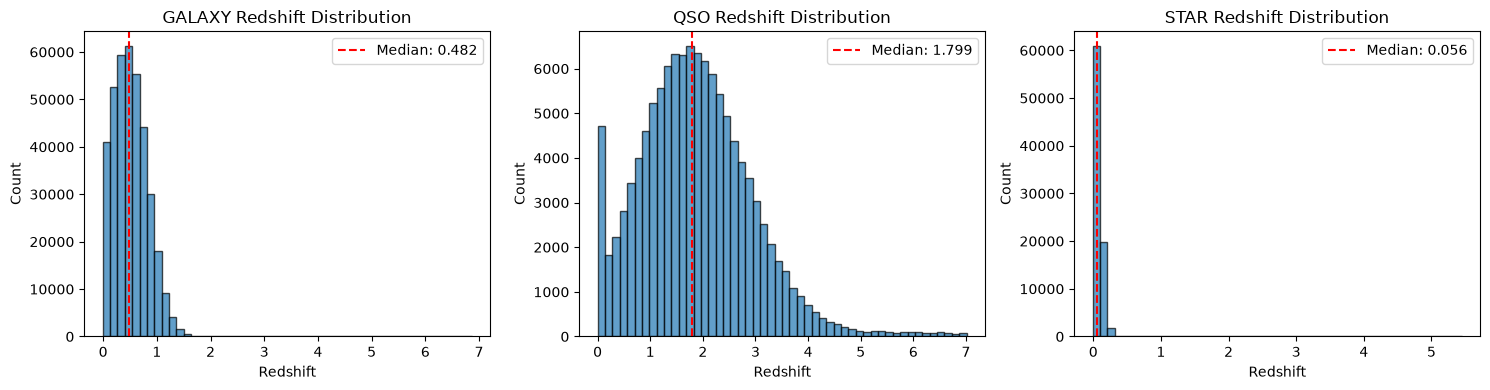

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls in zip(axes, ['GALAXY', 'QSO', 'STAR']):
    data = train[train['class'] == cls]['redshift']
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{cls} Redshift Distribution')
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/redshift_distribution.png', dpi=150)
plt.show()

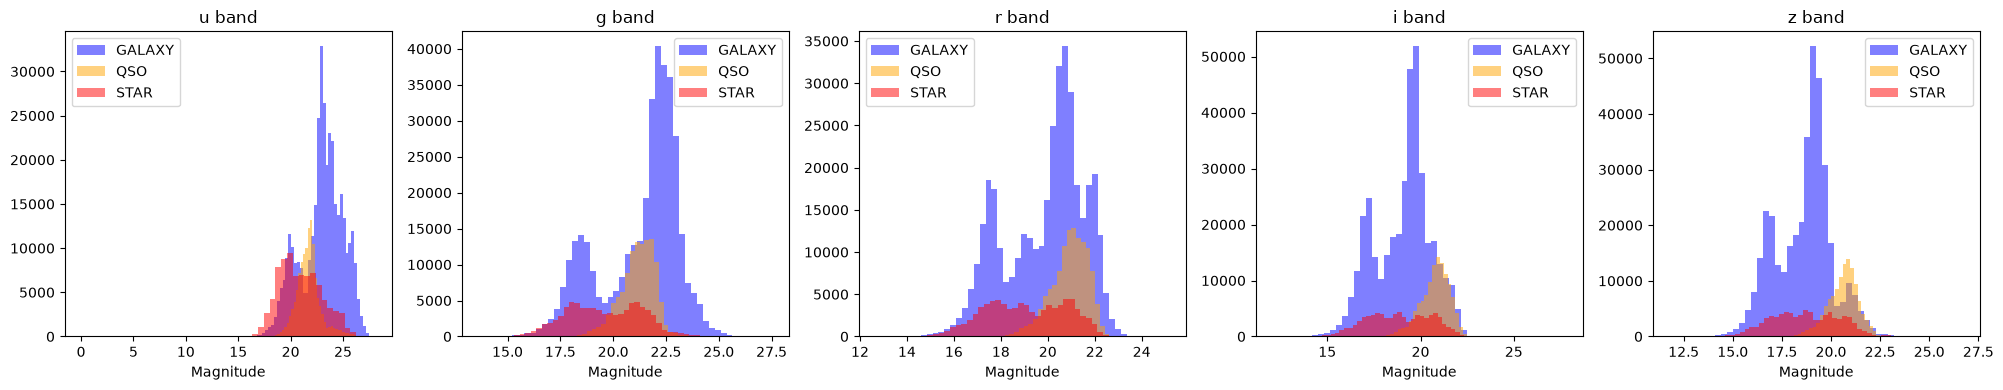

In [17]:
bands = ['u', 'g', 'r', 'i', 'z']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, band in zip(axes, bands):
    for cls, color in zip(['GALAXY', 'QSO', 'STAR'], ['blue', 'orange', 'red']):
        data = train[train['class'] == cls][band]
        ax.hist(data, bins=50, alpha=0.5, color=color, label=cls, edgecolor='none')
    ax.set_title(f'{band} band')
    ax.set_xlabel('Magnitude')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/band_distributions.png', dpi=150)
plt.show()

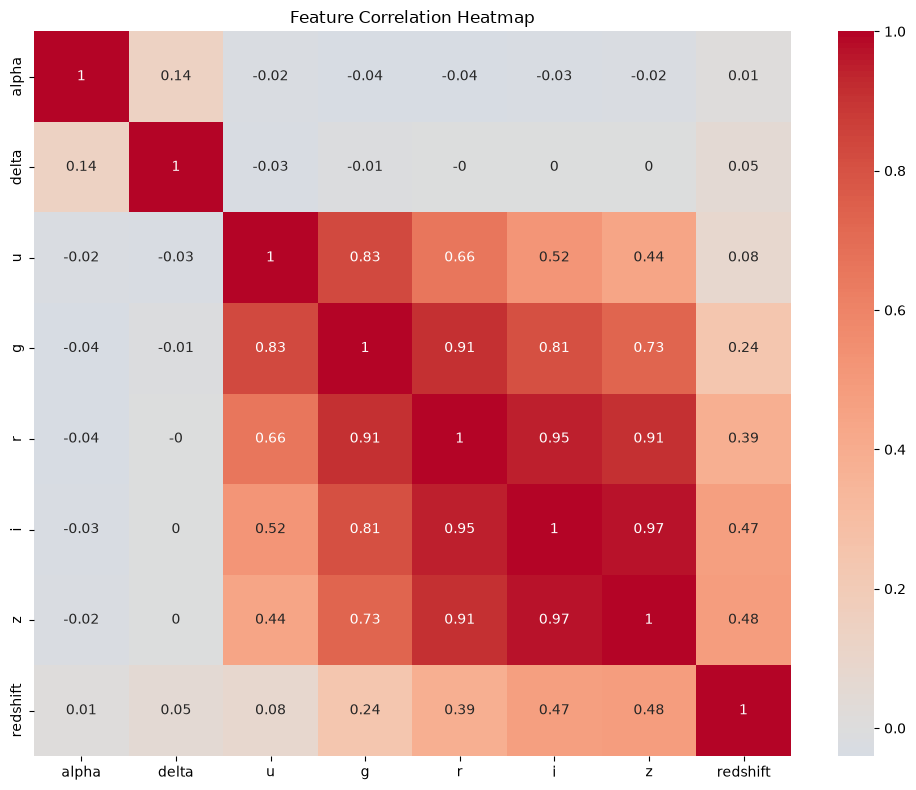

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
corr = train[numeric_cols].corr().round(2)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

In [19]:
# Add color indices to both train and test
for df in [train, test]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    
print("Color indices added successfully")
print("New train shape:", train.shape)
print("New test shape:", test.shape)

Color indices added successfully
New train shape: (577347, 16)
New test shape: (247435, 15)


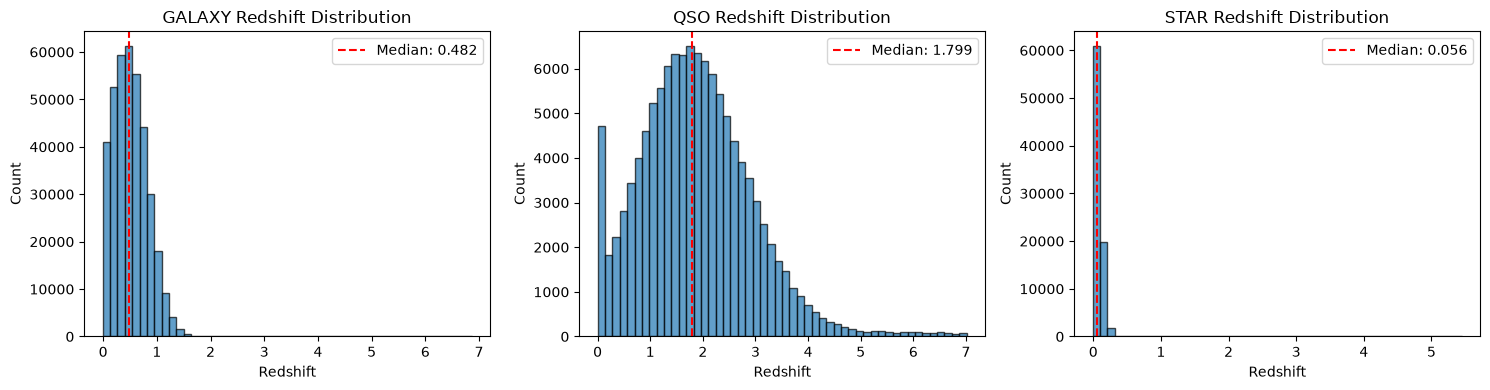

In [20]:
# Redshift distribution by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls in zip(axes, ['GALAXY', 'QSO', 'STAR']):
    data = train[train['class'] == cls]['redshift']
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{cls} Redshift Distribution')
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='red', 
               linestyle='--', 
               label=f'Median: {data.median():.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/redshift_distribution.png', dpi=150)
plt.show()

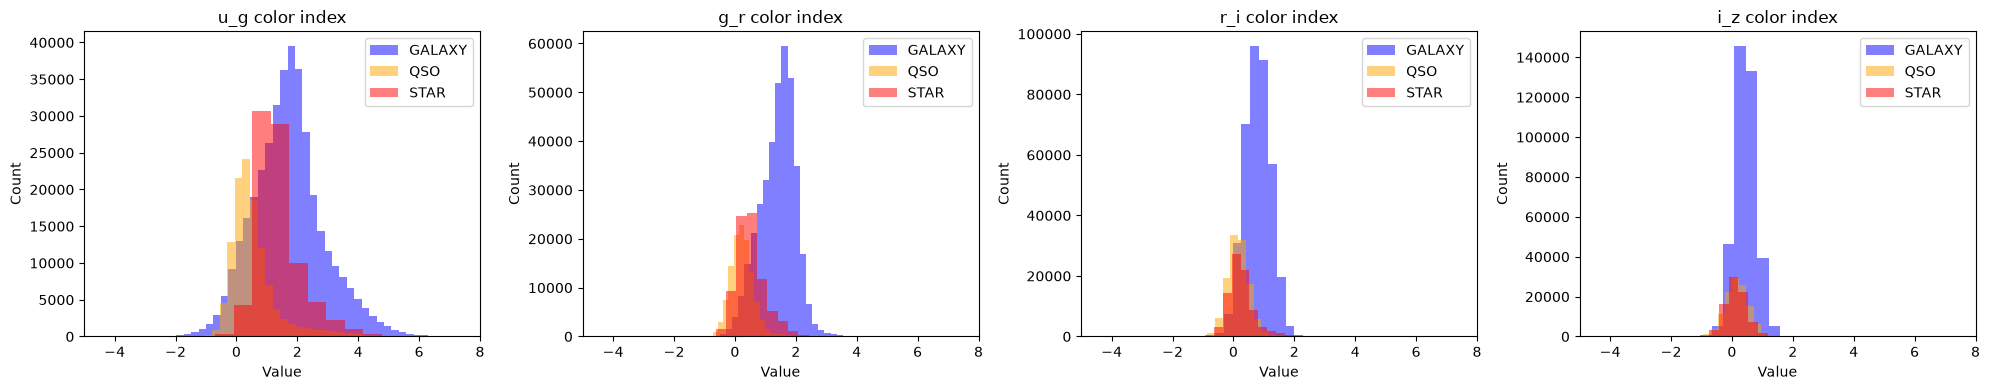

In [21]:
color_indices = ['u_g', 'g_r', 'r_i', 'i_z']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, idx in zip(axes, color_indices):
    for cls, color in zip(['GALAXY', 'QSO', 'STAR'], 
                          ['blue', 'orange', 'red']):
        data = train[train['class'] == cls][idx]
        ax.hist(data, bins=50, alpha=0.5, 
                color=color, label=cls, edgecolor='none')
    ax.set_title(f'{idx} color index')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_xlim(-5, 8)

plt.tight_layout()
plt.savefig('../outputs/color_indices.png', dpi=150)
plt.show()

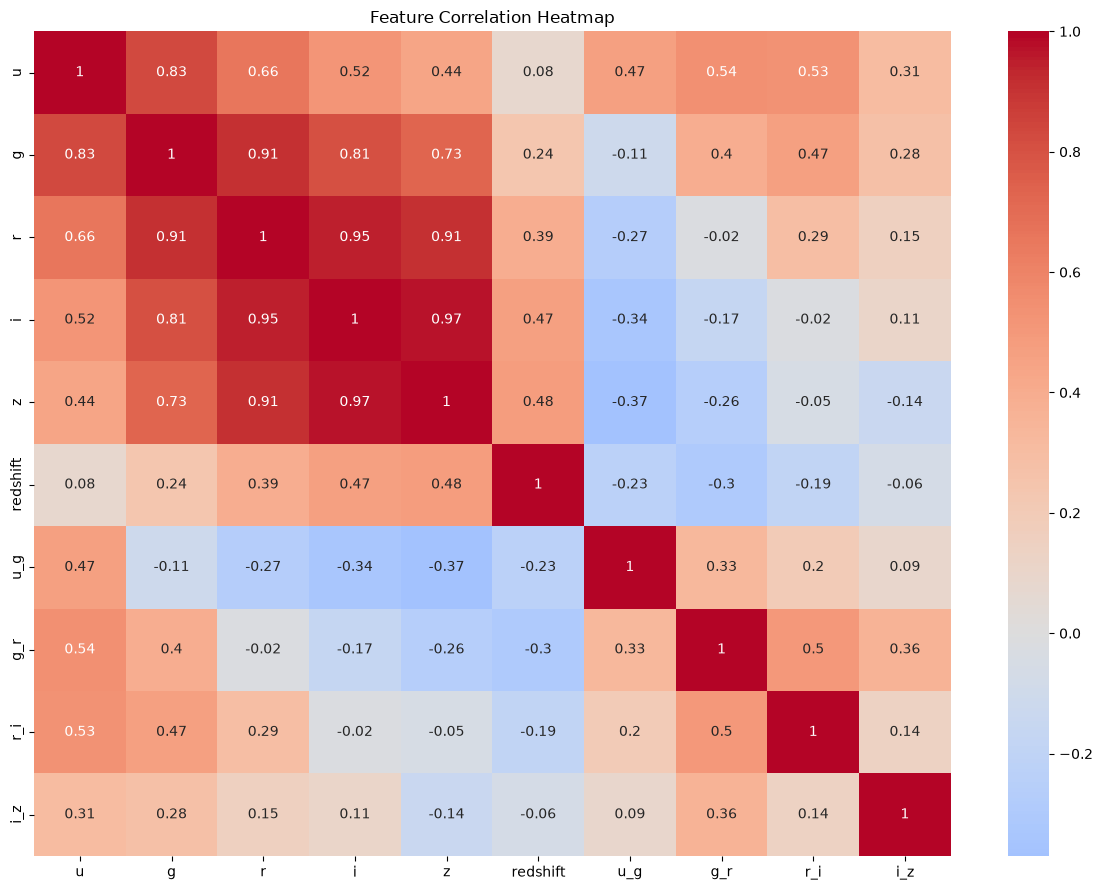

In [22]:
fig, ax = plt.subplots(figsize=(12, 9))

numeric_cols = ['u', 'g', 'r', 'i', 'z', 'redshift', 
                'u_g', 'g_r', 'r_i', 'i_z']
corr = train[numeric_cols].corr().round(2)

sns.heatmap(corr, annot=True, cmap='coolwarm', 
            center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()